# Objective
Predict the user’s addiction level (Low/Medium/High) based on Gen-Z social media behavior to understand how usage patterns relate to digital addiction.

# Approach

* Data Understanding
Explore 1M user dataset
Check distributions, missing values, and target balance

* Exploratory Data Analysis (EDA)
Analyze relationships between:
screen time ↔ addiction level
mental health ↔ usage behavior
platform preference patterns


* Preprocessing
Encode categorical variables (gender, country, platform, purpose)
Scale numerical features (usage hours, session time, etc.)


* Model Building
Split data into train/test sets
Train a classification model (e.g., Random Forest)


* Evaluation
Accuracy, precision, recall, F1-score
Analyze feature importance

# Import Libraries¶

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score

# Load Dataset

In [2]:
# Load CSV File
df = pd.read_csv('/kaggle/input/datasets/sharmajicoder/gen-z-social-media-usage-dataset/genz_social_media_usage_1M.csv')

# View Data
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


# Basic Data Understanding

In [3]:
# Shape of Dataset
print("Rows, Columns:", df.shape)

# Data Types
df.info()

# Missing Values Check
df.isnull().sum()

Rows, Columns: (1000000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  object 
 2   country                   1000000 non-null  object 
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  object 
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  object 
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  object 
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 91.6+ M

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

# Exploratory Data Analysis

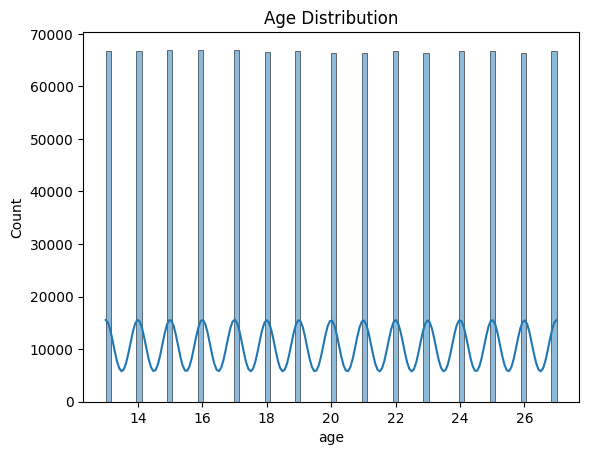

In [4]:
# Distribution Of Age
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

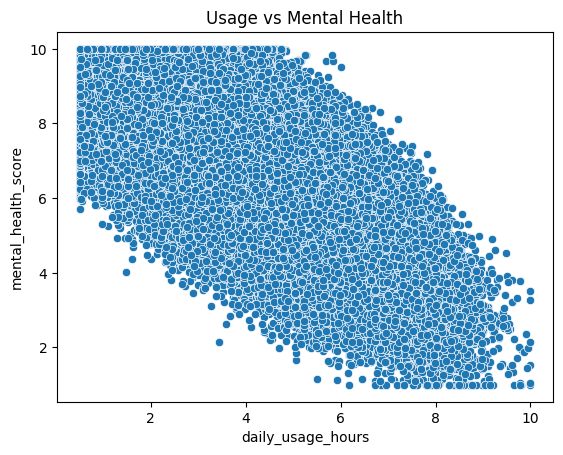

In [5]:
# Screen Time Vs Mental Helath
sns.scatterplot(x='daily_usage_hours', y='mental_health_score', data=df)
plt.title("Usage vs Mental Health")
plt.show()


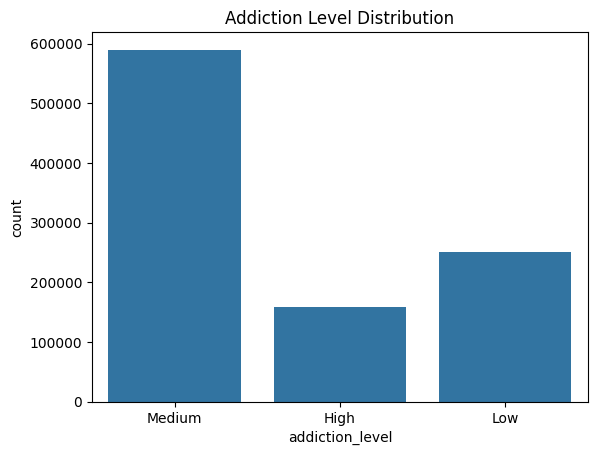

In [6]:
# Addiction Level Count
sns.countplot(x='addiction_level', data=df)
plt.title("Addiction Level Distribution")
plt.show()

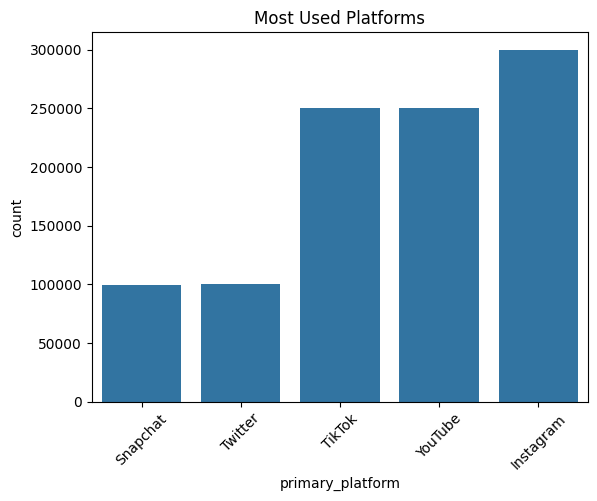

In [7]:
# Platform Usage
sns.countplot(x='primary_platform', data=df)
plt.xticks(rotation = 45)
plt.title("Most Used Platforms")
plt.show()

# Data Preprocessing

In [8]:
# Define Features and Target
X = df.drop('addiction_level', axis=1)
y = df['addiction_level']

In [9]:
# Identify Column Types
cat_cols = ['gender', 'country', 'primary_platform', 'purpose']
num_cols = ['age', 'daily_usage_hours', 'num_platforms_used',
            'avg_session_minutes', 'mental_health_score',
            'screen_time_before_sleep', 'night_usage']

In [10]:
# Create Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),   # Normalize numbers
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)  # Encode categories
])

# Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model Pipeline

In [12]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    
])

# Train Model

In [13]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'daily_usage_hours',
                                                   'num_platforms_used',
                                                   'avg_session_minutes',
                                                   'mental_health_score',
                                                   'screen_time_before_sleep',
                                                   'night_usage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country',
                                                   'primary_platform',
                                                   'purpose'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

# Predictions

In [14]:
y_pred = model.predict(X_test)

# Evaluation

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy: 0.999995
Classification Report:               precision    recall  f1-score   support

        High       1.00      1.00      1.00     31804
         Low       1.00      1.00      1.00     50071
      Medium       1.00      1.00      1.00    118125

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



# Feature Importance

In [ ]:
# Extract Model
rf = model.named_steps['classifier']

# Get feature names after encoding
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat = ohe.get_feature_names_out(cat_cols)

all_features = np.concatenate([num_cols, encoded_cat])

# Importance
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

# Insight
* Higher daily usage and late-night activity strongly indicate higher addiction levels.
* Increased addiction is linked with lower mental health scores.
* Users active on multiple platforms tend to show more intensive usage behavior.
* Screen time before sleep is a strong predictor of addictive social media patterns.
* Behavioral features together can reliably predict addiction risk among Gen-Z users.